In [27]:
import math 
import matplotlib.pyplot as plt
from collections import Counter

In [28]:
class KNN:
    def __init__(self, k=5): #testar com K = 1, 3, 5, 7, 9
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def distancia(self, a, b):
        soma = 0
        for i in range(len(a)):
            soma += (a[i] - b[i]) ** 2
        return math.sqrt(soma)

    def predict_one(self, x):
        distancias = []

        for i in range(len(self.X_train)):
            d = self.distancia(x, self.X_train[i])
            distancias.append((d, self.y_train[i]))

        distancias.sort(key=lambda x: x[0])

        vizinhos = distancias[:self.k]
        classes = [classe for _, classe in vizinhos]

        return Counter(classes).most_common(1)[0][0]

    def predict(self, X):
        return [self.predict_one(x) for x in X]

In [29]:
def carregar_csv(caminho):
    X = []
    y = []

    with open(caminho, "r") as f:
        for linha in f:
            partes = linha.strip().split(",")

            atributos = list(map(int, partes[:9]))
            classe = partes[9]

            X.append(atributos)
            y.append(classe)

    return X, y


X, y = carregar_csv("/home/gustavo-munoz-dutra/Documentos/t1_IA/dataset_treino.csv")

In [30]:
split = int(0.9 * len(X))  # ajustado pra bater com ~886/98

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 797
Teste: 89


In [31]:
def acuracia(y_real, y_pred):
    acertos = sum(1 for i in range(len(y_real)) if y_real[i] == y_pred[i])
    return acertos / len(y_real)

In [32]:
def calcular_metricas(y_real, y_pred):
    classes = list(set(y_real))
    resultados = {}

    for classe in classes:
        tp = fp = fn = tn = 0

        for i in range(len(y_real)):
            if y_real[i] == classe and y_pred[i] == classe:
                tp += 1
            elif y_real[i] != classe and y_pred[i] == classe:
                fp += 1
            elif y_real[i] == classe and y_pred[i] != classe:
                fn += 1
            else:
                tn += 1

        precision = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

        resultados[classe] = {
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

    return resultados


def media_metricas(metricas):
    precisions = []
    recalls = []
    f1s = []

    for valores in metricas.values():
        precisions.append(valores["precision"])
        recalls.append(valores["recall"])
        f1s.append(valores["f1"])

    return (
        sum(precisions)/len(precisions),
        sum(recalls)/len(recalls),
        sum(f1s)/len(f1s)
    )

In [33]:
ks = [1, 3, 5, 7, 9, 11]

acuracias = []
precisions_medias = []
recalls_medios = []
f1s_medios = []

for k in ks:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    acc = acuracia(y_test, pred)
    acuracias.append(acc)

    metricas = calcular_metricas(y_test, pred)
    p, r, f = media_metricas(metricas)

    precisions_medias.append(p)
    recalls_medios.append(r)
    f1s_medios.append(f)

    print(f"\nK={k}")
    print(f"Acurácia: {acc:.4f}")
    print(f"Precision média: {p:.4f}")
    print(f"Recall médio: {r:.4f}")
    print(f"F1 médio: {f:.4f}")


K=1
Acurácia: 0.5730
Precision média: 0.5789
Recall médio: 0.5596
F1 médio: 0.5654

K=3
Acurácia: 0.6966
Precision média: 0.6810
Recall médio: 0.6771
F1 médio: 0.6707

K=5
Acurácia: 0.6966
Precision média: 0.6626
Recall médio: 0.6842
F1 médio: 0.6672

K=7
Acurácia: 0.6517
Precision média: 0.6269
Recall médio: 0.6365
F1 médio: 0.6206

K=9
Acurácia: 0.6742
Precision média: 0.6206
Recall médio: 0.6559
F1 médio: 0.6286

K=11
Acurácia: 0.6292
Precision média: 0.5834
Recall médio: 0.6136
F1 médio: 0.5953


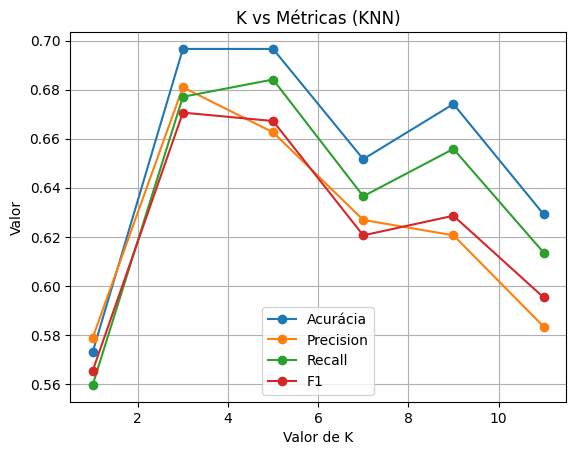

In [34]:
plt.figure()

plt.plot(ks, acuracias, marker='o', label="Acurácia")
plt.plot(ks, precisions_medias, marker='o', label="Precision")
plt.plot(ks, recalls_medios, marker='o', label="Recall")
plt.plot(ks, f1s_medios, marker='o', label="F1")

plt.title("K vs Métricas (KNN)")
plt.xlabel("Valor de K")
plt.ylabel("Valor")
plt.legend()
plt.grid()

plt.show()

In [35]:
melhor_k = ks[acuracias.index(max(acuracias))]
print("Melhor K:", melhor_k)

Melhor K: 3


In [36]:
def tabuleiro_para_vetor(tab):
    vetor = []

    for linha in tab:
        for c in linha:
            if c == 'X':
                vetor.append(1)
            elif c == 'O':
                vetor.append(-1)
            else:
                vetor.append(0)

    return vetor

In [37]:
knn = KNN(k=melhor_k)
knn.fit(X_train, y_train)

tabuleiro = [
    ['X', 'O', 'X'],
    ['O', 'X', ' '],
    [' ', 'O', ' ']
]

vetor = tabuleiro_para_vetor(tabuleiro)
estado = knn.predict_one(vetor)

print("Estado do jogo:", estado)

Estado do jogo: Tem jogo
